# Poker Hand Classification

**Course:** AAI 500  
**Team:** [Team number]  
**Contributors:** [Team member names]  
**Submission date:** [Date]

> **Working draft:** Replace the bracketed details and complete the analysis prompts before submitting. The model sections below are planning placeholders.

## 1. Introduction

This project explores the UCI Poker Hand dataset and investigates how classification models identify five-card poker hands using the suit and rank of each card.

**Research question:** How accurately can classification models identify poker hands, and how does performance differ between common and rare hand categories?

The analysis follows data preparation, exploratory data analysis, model selection, and model evaluation. A possible application is a poker education tool; the final discussion should consider whether a learned model offers value compared with a rule-based hand evaluator.

**Data source:** Cattral, R., & Oppacher, F. (2002). *Poker Hand*. UCI Machine Learning Repository. [Dataset and documentation](https://doi.org/10.24432/C5KW38).

## 2. Data Cleaning and Preparation

### 2.1 Load the dataset

Fetch the dataset from UCI. `X` contains the input features, `y` contains the hand category, and `data` combines both for inspection. Run this cell before the cells that use these variables.

In [8]:
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

poker_hand = fetch_ucirepo(id=158)

X = poker_hand.data.features
y = poker_hand.data.targets

data = X.join(y)

### 2.2 Preview the records

**Table 1. First ten records, including the target category.**

This preview shows the column layout and example values. Use the full-dataset summaries below to assess the overall distribution.

In [9]:
data.head(100)

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9
...,...,...,...,...,...,...,...,...,...,...,...
95,3,12,2,12,2,8,3,11,1,6,1
96,3,7,1,8,1,7,4,12,2,8,2
97,1,9,4,6,4,9,2,9,1,1,3
98,3,10,1,7,4,7,4,6,1,11,1


### 2.3 Identify the features and target

| Columns | Meaning | Interpretation |
| :--- | :--- | :--- |
| `S1` to `S5` | Suit of each card, coded 1 to 4 | Suit codes identify categories; their numeric values do not indicate strength. |
| `C1` to `C5` | Rank of each card, coded 1 to 13 | Ace is coded 1, Jack 11, Queen 12, and King 13. |
| `CLASS` | Poker hand category, coded 0 to 9 | Target label for classification. |

**Tables 2 and 3. Five example feature rows and their corresponding target labels.**

In [3]:
from IPython.display import display

display(X.head())
display(y.head())

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5
0,1,10,1,11,1,13,1,12,1,1
1,2,11,2,13,2,10,2,12,2,1
2,3,12,3,11,3,13,3,10,3,1
3,4,10,4,11,4,1,4,13,4,12
4,4,1,4,13,4,12,4,11,4,10


,CLASS
0,9
1,9
2,9
3,9
4,9


### 2.4 Dataset dimensions

Count the records and columns. The combined dataframe includes the ten input features and the target column.

In [4]:
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

Rows: 1,025,010
Columns: 11


### 2.5 Missing-value checks

Count the missing values in each column. A count of zero means no missing values were found in that column.

In [5]:
data.isna().sum()

S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

**Preparation notes to complete:** Record the outcome of the checks. Before modeling, also validate suit and rank ranges, check for repeated cards within a hand, investigate repeated hands, and document the feature encoding and data-splitting decisions. Explain any changes made to the data.

## 3. Exploratory Data Analysis

### 3.1 Hand category frequencies

Count the number of records in each target category. The code-to-label mapping below helps interpret the counts and chart.

| Code | Hand category |
| ---: | :--- |
| 0 | No recognized combination (high card) |
| 1 | One pair |
| 2 | Two pairs |
| 3 | Three of a kind |
| 4 | Straight |
| 5 | Flush |
| 6 | Full house |
| 7 | Four of a kind |
| 8 | Straight flush, excluding royal flush |
| 9 | Royal flush |

**Table 4. Number of records in each hand category across the full dataset.**

In [6]:
class_counts = data["CLASS"].value_counts().sort_index()

class_counts

CLASS
0    513702
1    433097
2     48828
3     21634
4      3978
5      2050
6      1460
7       236
8        17
9         8
Name: count, dtype: int64

### 3.2 Visualize the category distribution

Compare category counts using a bar chart. Small bars may be difficult to see on a linear scale, so refer to the exact counts in Table 4 when discussing rare categories.

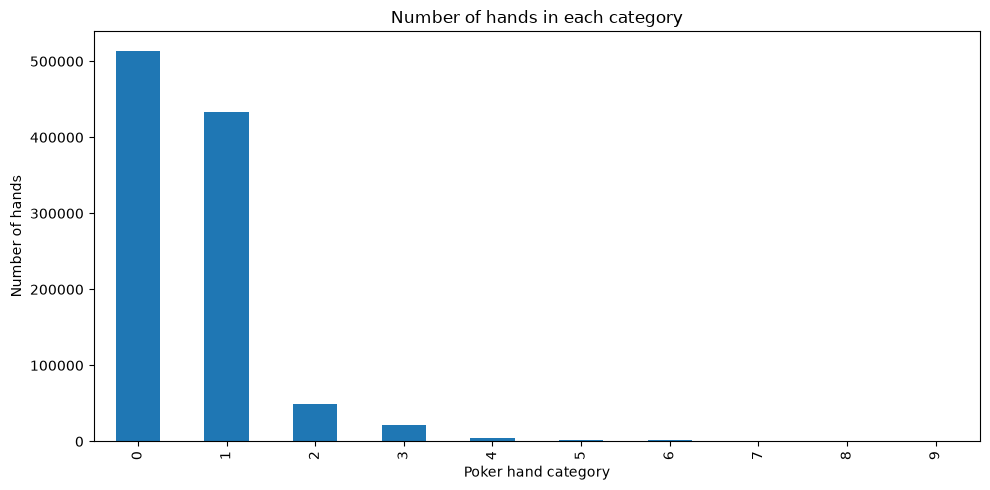

In [7]:
class_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Number of hands in each category",
)

plt.xlabel("Poker hand category")
plt.ylabel("Number of hands")
plt.tight_layout()
plt.show()

*Figure 1. Number of poker hands in each target category. The horizontal axis uses the category codes listed above; the vertical axis shows the number of records.*

### 3.3 Hand category distribution

The most common category is ______.

The least common category is ______.

This difference could affect model evaluation because ______.

## 4. Model Selection

*To complete after data preparation and exploration.*

- Define the prediction task, feature representation, and training/validation/test split.
- Describe the baseline and candidate classifiers, including the reason for each choice.
- Document any treatment of class imbalance and the settings compared.
- Select the final model using validation results and explain the statistical evidence supporting the choice. Reserve the test set for the final evaluation.

Add the model code and comparison results below this section as the project develops.

## 5. Model Analysis

*To complete after selecting and evaluating the final model.*

Present performance on the held-out test data, including a confusion matrix, accuracy, macro F1, and per-class precision and recall. State the number of examples supporting each class result and discuss uncertainty, especially for rare categories.

Explain the main errors, possible overfitting, and limitations. Include the statistical reasoning behind the evaluation and distinguish measured results from interpretations.

## 6. Conclusion and Recommendations

*To complete after model analysis.*

Summarize the answer to the research question, identify the selected model, and support the conclusion with the final evaluation results. Explain the practical implications for a non-technical reader.

Discuss limitations and recommend next steps. Compare the value of a learned classifier with the fixed rules that define poker hand categories.

---

**Submission preparation:** Replace the draft details and prompts, check that the notebook runs from top to bottom, and save the completed outputs before exporting. Use the completed notebook, with its code and outputs visible, as the technical appendix to the final report. Check the HTML or PDF preview for clipped tables and split figures.